# Ranking flagged journal entries: a demo on synthetic data

An audit team runs a dozen simple tests over a general ledger and gets thousands of flagged lines,
far more than anyone can review. This notebook ranks them so the review starts with the lines
most likely to matter, then checks the ranking against anomalies injected into the ledger on
purpose.

1. Generate a ledger with known anomalies.
2. Run the Python tests, and load the IDEA tests from mock exports.
3. Consolidate everything on the row ID and score it.
4. Check the priority list against the ground truth.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from glrisk import benford, evaluate, flags, pipeline, plots, rules, scoring, synthetic

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 12)

## 1. A synthetic ledger

20,000 journal lines over a year, Debit/Credit layout, with a row ID (`Sr No`) tagged first.
Normal business includes things the tests will flag anyway: round rent payments, director fees,
a supplier on fixed prices, the odd weekend posting and double postings. About 0.5% of lines are
injected anomalies with a larger amount. Most carry one to four red flags; a tenth are "silent",
with nothing for any test to find. They are marked in `Anomaly`, which the tests and the scoring
never read.

In [2]:
ledger = synthetic.make_ledger(20_000, seed=0)
amount_cols = synthetic.amount_columns(ledger)
print(f"{len(ledger):,} lines, {(ledger['Anomaly'] != '').sum()} injected anomalies")
ledger[ledger["Anomaly"] != ""].head()

20,050 lines, 100 injected anomalies


,Sr No,Date,Account,Description,Created By,Approved By,Debit,Credit,Anomaly
62,63,2025-01-01,Cost of Sales,Adjustment per director,user_a,manager_1,0.00,68926.12,keyword
202,203,2025-01-03,Suspense Account 22,Utility bill,user_c,manager_1,0.00,76684.47,seldom_account
981,982,2025-01-18,Payroll Expense,Customer receipt,user_b,manager_1,0.00,28999.00,ending_99+weekend
983,984,2025-01-18,Accounts Payable,Consultancy fee (related party),user_d,manager_1,0.00,40000.00,keyword+round_amount+weekend
1027,1028,2025-01-20,Suspense Account 20,Accrual,user_e,manager_2,28456.75,0.00,seldom_account


## 2. The tests

Python runs the date, amount and keyword tests. IDEA runs Benford, the seldom account summary, the
duplicate check and segregation of duties; here its exports are the mock files in
`fixtures/idea_exports` (see `idea/README.md`). Each test becomes a set of row IDs.

In [3]:
python_flags = pipeline.run_python_tests(ledger, amount_cols)
idea_flags = flags.load_idea_flags("../fixtures/idea_exports")

pd.DataFrame({
    "Source": ["Python"] * len(python_flags) + ["IDEA"] * len(idea_flags),
    "Test": [*python_flags, *idea_flags],
    "Lines flagged": [len(v) for v in [*python_flags.values(), *idea_flags.values()]],
}).assign(**{"% of ledger": lambda t: (t["Lines flagged"] / len(ledger) * 100).round(2)})

,Source,Test,Lines flagged,% of ledger
0,Python,Suspicious Keyword,799,3.99
1,Python,Rounded Amount,231,1.15
2,Python,Ending 99/999,49,0.24
3,Python,Public Holiday,697,3.48
4,Python,Saturday,155,0.77
5,Python,Sunday,181,0.90
6,IDEA,Benford,2408,12.01
7,IDEA,Duplicate,102,0.51
8,IDEA,Seldom Account Entries,39,0.19
9,IDEA,SoD Violation Entries,40,0.20


The Benford test on the whole ledger: the fixed-price supplier pushes the digit 4 above its
expected share. The overall MAD still says the ledger conforms, which is why Benford gets a low
prior: on its own it rarely points at a problem.

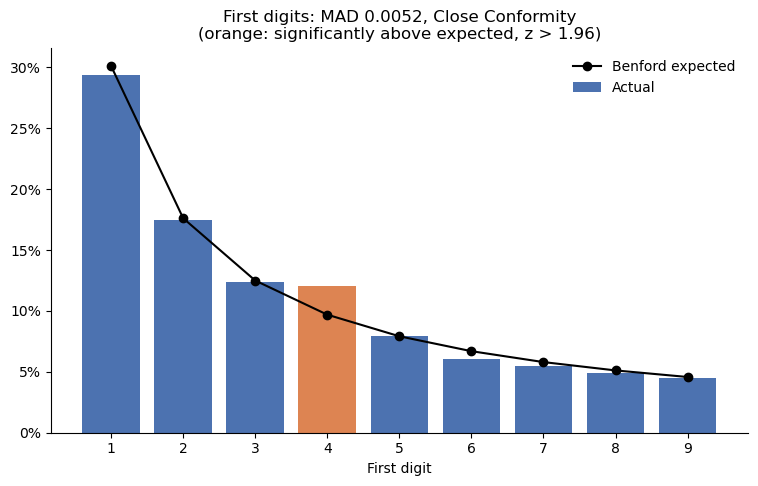

In [4]:
table = benford.first_digit_test(rules.absolute_amount(ledger, amount_cols))
plots.benford_chart(table)
plt.show()

## 3. Consolidate and score

`consolidate` gives one row per line with a column per test. The score then weights each test by
**rarity in this ledger x prior**, counts the date tests once (a Saturday that is also a public
holiday is one calendar signal, not two), scales Benford by amount diversity, and multiplies by
`1 + log10(1 + amount / median amount)`. The priors here are illustrative.

4,289 lines flagged by at least one test (21% of the ledger)


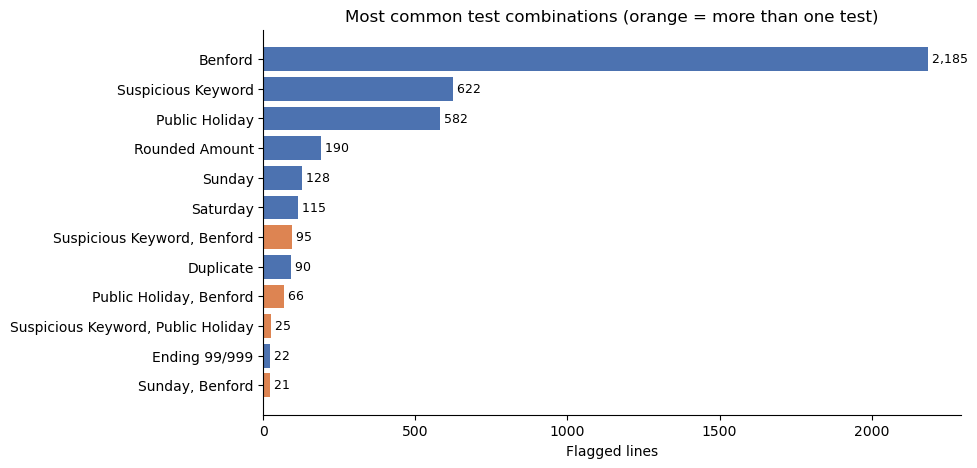

In [5]:
flagged = flags.consolidate(ledger, python_flags, idea_flags)
print(f"{len(flagged):,} lines flagged by at least one test "
      f"({len(flagged) / len(ledger):.0%} of the ledger)")
plots.flag_overlap(flagged)
plt.show()

In [6]:
scored = scoring.score_flags(flagged, amount_cols, top_n=None)
pd.Series(scored.attrs["weights"], name="Weight").sort_values(ascending=False).to_frame()

,Weight
Seldom Account Entries,6.778
Ending 99/999,3.918
Suspicious Keyword,3.499
Duplicate,3.440
Rounded Amount,2.908
SoD Violation Entries,2.700
Saturday,1.056
Sunday,1.022
Public Holiday,0.729
Benford,0.460


In [7]:
k = scoring.priority_list_size(len(ledger))
priority = scored.head(k)
print(f"Priority list: {k} lines (0.577 x sqrt({len(ledger):,}), within 20-150)")
priority[["Sr No", "Date", "Account", "Description", *amount_cols, "Score"]].head(10)

Priority list: 82 lines (0.577 x sqrt(20,050), within 20-150)


,Sr No,Date,Account,Description,Debit,Credit,Score
3347,3348,2025-03-04,Suspense Account 9,Write off - settlement,0.00,87999.0,39.788
7389,7390,2025-05-19,Suspense Account 13,Write off - settlement,133999.00,0.0,35.928
2487,2488,2025-02-14,Suspense Account 49,"Cash advance, no invoice",102999.00,0.0,34.366
18686,18687,2025-12-07,Suspense Account 30,"Cash advance, no invoice",46999.00,0.0,32.906
8626,8627,2025-06-10,Suspense Account 37,Customer receipt,0.00,170000.0,32.600
5464,5465,2025-04-12,Suspense Account 45,Correction entry - reversal,75370.53,0.0,32.150
18649,18650,2025-12-05,Suspense Account 12,Consultancy fee (related party),0.00,69999.0,32.095
8916,8917,2025-06-13,Suspense Account 42,Prepayment release,70999.00,0.0,30.369
17132,17133,2025-11-07,Suspense Account 8,Sales invoice,0.00,63999.0,29.793
6200,6201,2025-04-27,Suspense Account 17,Adjustment per director,31999.00,0.0,29.643


Each line carries its own explanation: the weight of every test it hit (date tests as one
term), times the amount multiplier. A reviewer can see why a line is where it is, and challenge it.

In [8]:
with pd.option_context("display.max_colwidth", None):
    display(priority[["Sr No", "Score", "Score Breakdown"]].head(5))

,Sr No,Score,Score Breakdown
3347,3348,39.788,"Seldom Account Entries 6.8 + Ending 99/999 3.9 + Suspicious Keyword 3.5 + SoD Violation Entries 2.7, × amount 2.35"
7389,7390,35.928,"Seldom Account Entries 6.8 + Ending 99/999 3.9 + Suspicious Keyword 3.5, × amount 2.53"
2487,2488,34.366,"Seldom Account Entries 6.8 + Ending 99/999 3.9 + Suspicious Keyword 3.5, × amount 2.42"
18686,18687,32.906,"Seldom Account Entries 6.8 + Ending 99/999 3.9 + Suspicious Keyword 3.5 + date (Sunday) 1.0 + Benford 0.5, × amount 2.10"
8626,8627,32.600,"Seldom Account Entries 6.8 + Rounded Amount 2.9 + SoD Violation Entries 2.7, × amount 2.63"


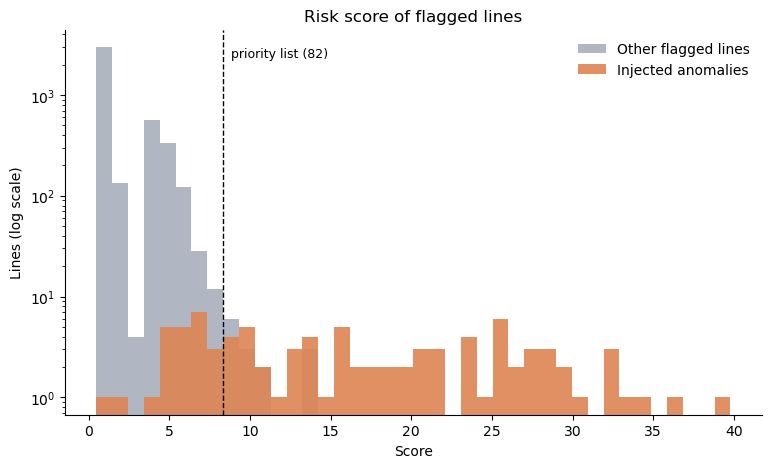

In [9]:
plots.score_distribution(scored, k)
plt.show()

## 4. Does the ranking find the injected anomalies?

Precision@k is the share of the priority list that are injected anomalies; recall@k is the share
of all anomalies that made the list. The baselines: the number of tests hit (a common manual
approach), an Isolation Forest on simple line features, amount alone, and a random order of the
flagged lines. The ceiling is the best any ranking of the flagged lines could do: the silent
anomalies trip no test, so its recall is below 1.

This is one seed, as a worked example; `docs/benchmark_results.md` has the mean and spread over 30
seeds, the ablation study and the sweeps.

In [10]:
results = evaluate.compare_rankings(scored, ledger, amount_cols, k, ml=True)
results

,Precision@82,Recall@82
Risk score,0.829,0.68
Number of tests hit,0.720,0.59
Amount only,0.305,0.25
Random flagged lines,0.024,0.02
Isolation Forest,0.598,0.49
Ceiling (flagged lines),1.000,0.91


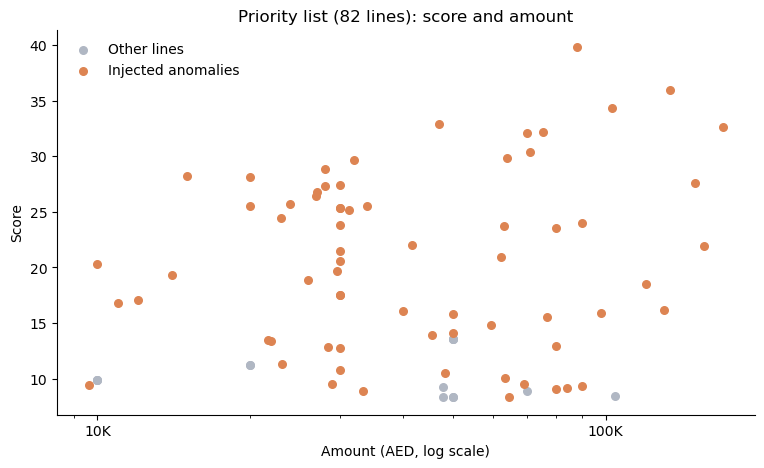

In [11]:
plots.priority_amounts(priority, amount_cols)
plt.show()

Counting tests treats a weekend posting the same as a posting to an account used twice a year.
Weighting by rarity separates them, and the amount multiplier lifts large entries with a single
rare flag, which a count of tests misses. On this ledger the risk score's priority list is more
precise than counting tests, the Isolation Forest and amount alone.

The anomalies come from the same generator the scoring was designed around, so these numbers
show the method works as intended. They are not a claim about real ledgers.